# 06 – Análise de Sobrevivência
**Objetivo:** Aplicar técnicas de análise de sobrevivência para estimar as funções de probabilidade de sobrevivência ao longo do tempo de internação e modelar o risco (hazard) utilizando a Regressão de Cox.

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# Configurações gráficas estritas conforme normas da instituição
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans", "Helvetica"],
    "font.size": 11,
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.5,
    "axes.facecolor": "none",
    "figure.facecolor": "none",
    "axes.grid": False,
    "xtick.color": "black",
    "ytick.color": "black",
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "axes.spines.top": False,
    "axes.spines.right": False
})
sns.set_style("white")
def enforce_tcc_style():
    import matplotlib.pyplot as plt
    import seaborn as sns
    try:
        plt.grid(False)
        sns.despine(top=True, right=True, left=False, bottom=False)
        for ax_ in plt.gcf().axes:
            ax_.grid(False)
            ax_.spines['top'].set_visible(False)
            ax_.spines['right'].set_visible(False)
            ax_.spines['bottom'].set_linewidth(1.5)
            ax_.spines['bottom'].set_color('black')
            ax_.spines['left'].set_linewidth(1.5)
            ax_.spines['left'].set_color('black')
            ax_.tick_params(colors='black', width=1.5)
            if ax_.get_title(): ax_.set_title('')
    except Exception: pass


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Lifelines (Survival Analysis library)
# pip install lifelines
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

# sns.set_theme(style='whitegrid') # SOBRESCRITO PELO TCC
plt.rcParams['figure.figsize'] = (10, 6)
FIG_PATH = Path('../reports/figures')
FIG_PATH.mkdir(parents=True, exist_ok=True)


## 1. Preparação dos Dados
A análise de sobrevivência requer a variável de **tempo** (`dias_permanencia` ou `tempo_sobrevida`). Como essas variáveis foram removidas da base reduzida (para evitar vazamento no ML), usaremos a **base_modelagem.csv** original e faremos uma seleção de features manuais de interesse clínico.


In [3]:
DATA_PATH = Path('../data/processed/base_modelagem.csv')
df = pd.read_csv(DATA_PATH, low_memory=False)

# Garantir formato correto
df['indicador_obito'] = pd.to_numeric(df['indicador_obito'], errors='coerce')
df['dias_permanencia'] = pd.to_numeric(df.get('quantidade_diarias', df.get('dias_permanencia', 0)), errors='coerce')
df['uti_mes_total'] = pd.to_numeric(df.get('uti_mes_total', df.get('uti_mes_total_cod', 0)), errors='coerce')

# Variáveis básicas para sobrevida
T = df['dias_permanencia']  # Tempo
E = df['indicador_obito']   # Evento (1 = Óbito, 0 = Censura/Alta)

print(f"Base carregada. Casos totais: {len(df)}")
print(f"Óbitos confirmados: {E.sum()}")


Base carregada. Casos totais: 415367
Óbitos confirmados: 38957


## 2. Estimador de Kaplan-Meier (Curva Global)
Plotar a curva de sobrevivência global da amostra ao longo dos dias de internação.

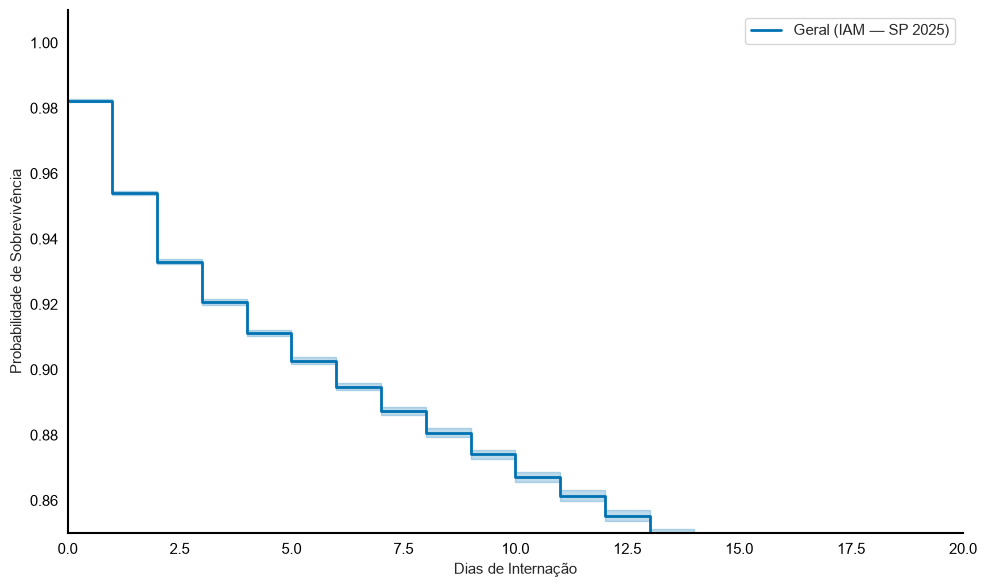

Figura salva em reports/figures/km_global.jpg
Mediana de sobrevivência: 115.0 dias


In [9]:
kmf = KaplanMeierFitter()
kmf.fit(durations=T, event_observed=E, label='Geral (IAM — SP 2025)')

fig, ax = plt.subplots(figsize=(10, 6))
kmf.plot_survival_function(ax=ax, color='#0072B2', linewidth=2)
# ax.set_title('Curva de Sobrevivência Kaplan-Meier — IAM (SP, 2025)', fontsize=13, fontweight='bold') # TÍTULO REMOVIDO PARA TCC
ax.set_ylabel('Probabilidade de Sobrevivência')
ax.set_xlabel('Dias de Internação')
ax.set_xlim(0, 20)
ax.set_ylim(0.85, 1.01)
# ax.grid(True, alpha=0.3) # GRID REMOVIDO PARA TCC
plt.tight_layout()
enforce_tcc_style()
plt.savefig(FIG_PATH / 'km_global.jpg', dpi=300, bbox_inches='tight')
plt.show()
print("Figura salva em reports/figures/km_global.jpg")
print(f"Mediana de sobrevivência: {kmf.median_survival_time_} dias")


## 3. Sobrevivência Estratificada
Comparar curvas de sobrevivência entre grupos (ex: Sexo, Caráter de Atendimento) usando o Log-Rank Test.

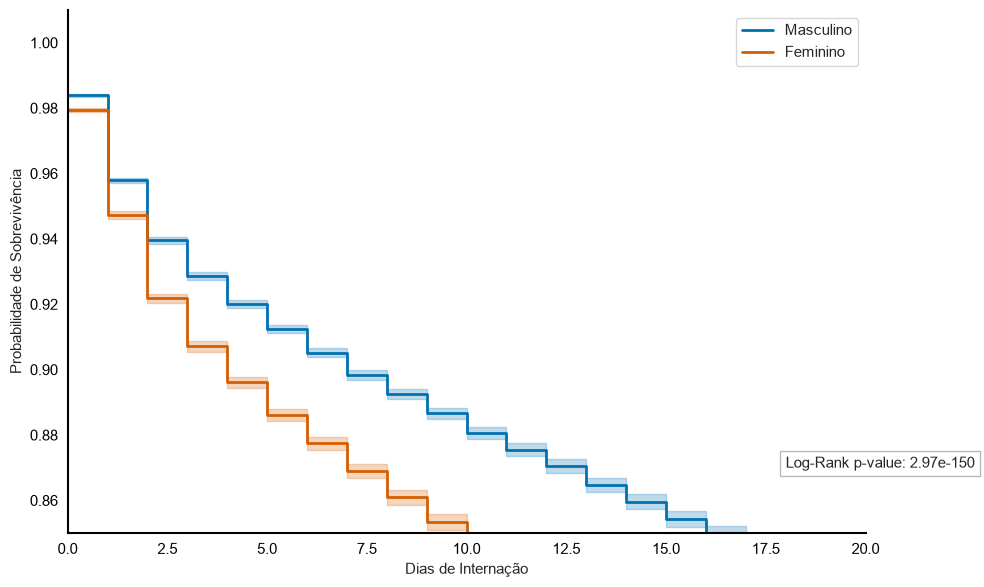

Figura salva em reports/figures/km_por_sexo.jpg
Log-Rank p-value: 2.9709e-150
Conclusão: Diferença estatisticamente significativa (p < 0.05)


In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

mask_m = df['sexo'] == 'Masculino'
mask_f = df['sexo'] == 'Feminino'

kmf_m = KaplanMeierFitter()
kmf_f = KaplanMeierFitter()

kmf_m.fit(T[mask_m], event_observed=E[mask_m], label='Masculino')
kmf_m.plot_survival_function(ax=ax, color='#0072B2', linewidth=2)

kmf_f.fit(T[mask_f], event_observed=E[mask_f], label='Feminino')
kmf_f.plot_survival_function(ax=ax, color='#D55E00', linewidth=2)

# ax.set_title('Curva de Sobrevivência por Sexo — IAM (SP, 2025)', fontsize=13, fontweight='bold') # TÍTULO REMOVIDO PARA TCC
ax.set_ylabel('Probabilidade de Sobrevivência')
ax.set_xlabel('Dias de Internação')
ax.set_xlim(0, 20)
ax.set_ylim(0.85, 1.01)
# ax.grid(True, alpha=0.3) # GRID REMOVIDO PARA TCC
ax.legend(fontsize=11)

# Log-Rank Test
results = logrank_test(T[mask_m], T[mask_f], event_observed_A=E[mask_m], event_observed_B=E[mask_f])
ax.text(18, 0.87, f"Log-Rank p-value: {results.p_value:.2e}", fontsize=11,
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='#999999'))

plt.tight_layout()
enforce_tcc_style()
plt.savefig(FIG_PATH / 'km_por_sexo.jpg', dpi=300, bbox_inches='tight')
plt.show()
print("Figura salva em reports/figures/km_por_sexo.jpg")
print(f"Log-Rank p-value: {results.p_value:.4e}")
print(f"Conclusão: {'Diferença estatisticamente significativa (p < 0.05)' if results.p_value < 0.05 else 'Sem diferença significativa'}")


## 3b. Sobrevivência por Estrutura Hospitalar

Avaliando se a sobrevida difere dependendo da qualidade estrutural do hospital de atendimento (indicador construído na base enriquecida).

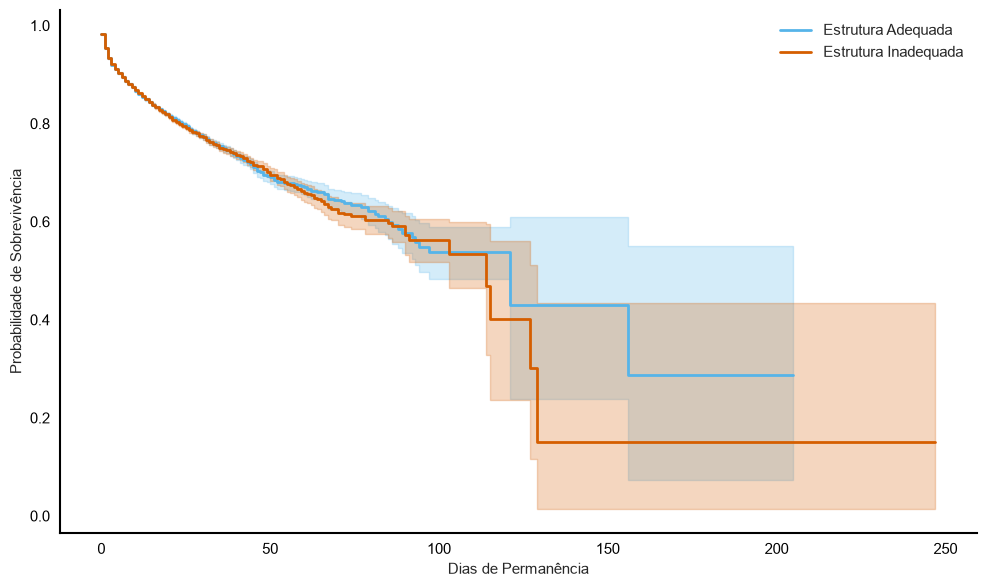

Figura salva em reports/figures/km_por_estrutura.jpg

=== Log-Rank Test (Adequada vs Inadequada) ===


In [6]:
# Carrega a base enriquecida para usar o indicador de estrutura
df_enriched = pd.read_csv(Path("..").resolve() / "data" / "processed" / "base_modelagem_enriched.csv", low_memory=False)

# Faz o merge do indicador para o df_cox ou base atual do notebook.
# Assumindo que df original ou df_cox compartilha o index, ou via codigo_cnes + mes, mas como os indices de linha devem ser os mesmos:
df["indicador_estrutura"] = df_enriched["indicador_estrutura"].values

fig, ax = plt.subplots(figsize=(10, 6))

mask_adeq = df["indicador_estrutura"] == "Adequada"
mask_inadeq = df["indicador_estrutura"] == "Inadequada"

kmf_adeq = KaplanMeierFitter()
kmf_inadeq = KaplanMeierFitter()

kmf_adeq.fit(T[mask_adeq], event_observed=E[mask_adeq], label="Estrutura Adequada")
kmf_adeq.plot_survival_function(ax=ax, color="#56B4E9", linewidth=2)

kmf_inadeq.fit(T[mask_inadeq], event_observed=E[mask_inadeq], label="Estrutura Inadequada")
kmf_inadeq.plot_survival_function(ax=ax, color="#D55E00", linewidth=2)

ax.set_ylabel("Probabilidade de Sobrevivência")
ax.set_xlabel("Dias de Permanência")
ax.legend(frameon=False)

plt.tight_layout()
enforce_tcc_style()
plt.savefig(FIG_PATH / "km_por_estrutura.jpg", dpi=300)
plt.show()
print("Figura salva em reports/figures/km_por_estrutura.jpg")

results_est = logrank_test(T[mask_adeq], T[mask_inadeq], event_observed_A=E[mask_adeq], event_observed_B=E[mask_inadeq])
print("\n=== Log-Rank Test (Adequada vs Inadequada) ===")
results_est.print_summary()

## 4. Modelo de Riscos Proporcionais de Cox (CoxPH)
O modelo de Cox permite avaliar o efeito de múltiplas variáveis independentes sobre o risco de ocorrência do óbito (Hazard Ratio).

=== Modelo de Riscos Proporcionais de Cox ===


<lifelines.CoxPHFitter: fitted with 415367 total observations, 376410 right-censored observations>
             duration col = 'dias_permanencia'
                event col = 'indicador_obito'
      baseline estimation = breslow
   number of observations = 415367
number of events observed = 38957
   partial log-likelihood = -472385.87
         time fit was run = 2026-09-03 17:07:03 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
idade               0.04      1.05      0.00            0.04            0.05                1.04                1.05
sexo                0.13      1.13      0.01            0.11            0.15                1.11                1.16
carater_internacao  0.56      1.75      0.03            0.51            0.61                1.67                1.84
usou_uti            0.54      1.72      0.01            0.52            0.56                1.68                1.75

                    cmp to      z      p  -log2(p)
covariate                                         
idade                 0.00 100.80 <0.005       inf
sexo                  0.00  12.15 <0.005    110.39
carater_internacao    0.00  22.20 <0.005    360.39
usou_uti              0.00  52.73 <0.005       inf
---
Concordance = 0.67
Partial AIC = 944779.73
log-likelihood ratio test = 14393.27 on 4 df
-log2(p) of ll-ratio test = inf

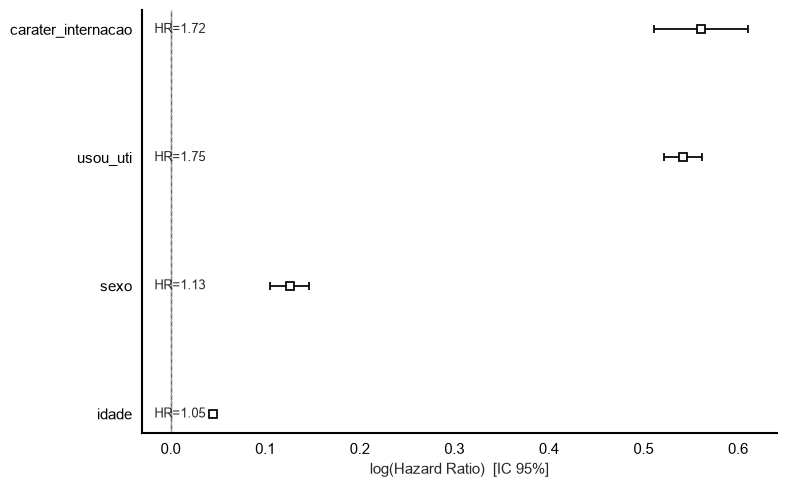

Figura salva em reports/figures/cox_hazard_ratios.jpg

INTERPRETAÇÃO DO HAZARD RATIO (exp(coef)):
- Valores > 1 indicam que a variável AUMENTA o risco de óbito.
- Valores < 1 indicam que a variável REDUZ o risco de óbito (proteção).

Concordance Index (C-statistic): 0.6716


In [7]:
cols_cox = ['dias_permanencia', 'indicador_obito', 'idade', 'sexo', 'carater_internacao', 'uti_mes_total']
df_cox = df[cols_cox].copy().dropna()
df_cox['sexo']               = (df_cox['sexo'] == 'Feminino').astype(int)
df_cox['carater_internacao'] = (df_cox['carater_internacao'] == 'Urgência').astype(int)
df_cox['usou_uti']           = (df_cox['uti_mes_total'] > 0).astype(int)
df_cox.drop(columns=['uti_mes_total'], inplace=True)

cph = CoxPHFitter()
cph.fit(df_cox, duration_col='dias_permanencia', event_col='indicador_obito')

print("=== Modelo de Riscos Proporcionais de Cox ===")
cph.print_summary()

# Plotar Hazard Ratios
fig, ax = plt.subplots(figsize=(8, 5))
cph.plot(ax=ax)
# ax.set_title('Hazard Ratios — Regressão de Cox (IAM, SP 2025)', fontsize=13, fontweight='bold') # TÍTULO REMOVIDO PARA TCC
ax.axvline(0, color='#999999', linestyle='--', linewidth=1)
ax.set_xlabel('log(Hazard Ratio)  [IC 95%]')

# Adicionar rótulos com valores do HR
for i, (covar, row) in enumerate(cph.params_.items()):
    hr = cph.hazard_ratios_[covar]
    ax.text(0.02, i, f"HR={hr:.2f}", va='center', fontsize=9, transform=ax.get_yaxis_transform())

plt.tight_layout()
enforce_tcc_style()
plt.savefig(FIG_PATH / 'cox_hazard_ratios.jpg', dpi=300, bbox_inches='tight')
plt.show()
print("Figura salva em reports/figures/cox_hazard_ratios.jpg")

print("\nINTERPRETAÇÃO DO HAZARD RATIO (exp(coef)):")
print("- Valores > 1 indicam que a variável AUMENTA o risco de óbito.")
print("- Valores < 1 indicam que a variável REDUZ o risco de óbito (proteção).")
print(f"\nConcordance Index (C-statistic): {cph.concordance_index_:.4f}")


## 5. Teste de Resíduos de Schoenfeld — Premissa de Riscos Proporcionais

O modelo de Cox assume que os **hazard ratios são constantes ao longo do tempo** (premissa de riscos proporcionais). O teste de resíduos de Schoenfeld testa formalmente essa premissa: **H₀: riscos são proporcionais** (resíduos sem tendência temporal). Um p-valor < 0,05 indica violação da premissa para aquela covariável.


In [8]:
from lifelines.statistics import proportional_hazard_test

results_schoenfeld = proportional_hazard_test(
    cph,
    df_cox,
    time_transform='rank'
)

print('=== Teste de Resíduos de Schoenfeld ===')
print('H0: riscos são proporcionais (sem tendência temporal nos resíduos)')
print()
results_schoenfeld.print_summary()
print()
for covar in cph.params_.index:
    row = results_schoenfeld.summary.loc[covar]
    p   = row['p']
    sig = '*** VIOLA' if p < 0.001 else ('** VIOLA' if p < 0.01 else
          ('* VIOLA' if p < 0.05 else 'OK (proporcional)'))
    print(f'  {covar:<25}  p = {p:.4e}  → {sig}')


=== Teste de Resíduos de Schoenfeld ===
H0: riscos são proporcionais (sem tendência temporal nos resíduos)




  idade                      p = 1.1849e-66  → *** VIOLA
  sexo                       p = 2.3549e-02  → * VIOLA
  carater_internacao         p = 5.9637e-01  → OK (proporcional)
  usou_uti                   p = 0.0000e+00  → *** VIOLA
